# Network Analysis

Sieci interakcji użytkowników w czterech muzycznych subredditach. Każdy węzeł to użytkownik, a każda krawędź oznacza, że ​​jeden użytkownik odpowiedział innemu.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from collections import Counter

from community import community_louvain

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/all_subreddits_sample.csv")
print(df.shape)
df[["author", "parent_id", "link_id", "subreddit"]].head()

(2544183, 10)


,author,parent_id,link_id,subreddit
0,Moron_on_Oxy-,t3_fglr4p,t3_fglr4p,hiphopheads
1,superchingonguey,t1_fk5o56t,t3_fgnnun,hiphopheads
2,Aniceguy96,t1_fk5mi66,t3_fglr4p,hiphopheads
3,Sushieatinbeast,t3_fgihaz,t3_fgihaz,hiphopheads
4,DocterJohnSmith,t1_fk5o548,t3_fglr4p,hiphopheads


## 1. Budowa sieci

In [4]:
# parent_id zaczyna sie od t1_ jesli to odpowiedz na komentarz
# t3_ oznacza odpowiedz na post (nie interesuje nas)
replies = df[df["parent_id"].str.startswith("t1_", na=False)].copy()

replies["parent_comment_id"] = replies["parent_id"].str[3:]

# laczemy z oryginalnym df zeby znalezc autora rodzica
edges = replies.merge(
    df[["comment_id", "author"]].rename(columns={"author": "parent_author"}),
    left_on="parent_comment_id",
    right_on="comment_id",
    how="inner"
)

# usuwamy self-loops
edges = edges[edges["author"] != edges["parent_author"]]

print(f"Znaleziono {len(edges)} krawedzi")
edges[["subreddit", "author", "parent_author"]].head(10)

Znaleziono 1540868 krawedzi


,subreddit,author,parent_author
0,hiphopheads,Vadermaulkylo,Moron_on_Oxy-
1,hiphopheads,dylwaybake,OH-PEACHY
2,hiphopheads,Aniceguy96,Moron_on_Oxy-
3,hiphopheads,Moron_on_Oxy-,Vadermaulkylo
4,hiphopheads,dadouks,Aniceguy96
5,hiphopheads,undercoverlurk,lndw20
6,hiphopheads,Moron_on_Oxy-,Aniceguy96
7,hiphopheads,Aniceguy96,dadouks
8,hiphopheads,Vadermaulkylo,Moron_on_Oxy-
9,hiphopheads,Aniceguy96,Moron_on_Oxy-


In [5]:
graphs = {}

for sub, group in edges.groupby("subreddit"):
    G = nx.DiGraph()
    
    for _, row in group.iterrows():
        G.add_edge(row["author"], row["parent_author"])
    
    graphs[sub] = G
    print(f"r/{sub}: {G.number_of_nodes()} wezlow, {G.number_of_edges()} krawedzi")

r/Metal: 11046 wezlow, 45632 krawedzi
r/hiphopheads: 83286 wezlow, 619011 krawedzi
r/indieheads: 32213 wezlow, 143111 krawedzi
r/popheads: 27179 wezlow, 317932 krawedzi


## 2. Podstawowe metryki

In [6]:
metrics = []

for sub, G in graphs.items():
    G_und = G.to_undirected()
    degrees = [d for _, d in G_und.degree()]
    
    metrics.append({
        "subreddit":   sub,
        "nodes":       G.number_of_nodes(),
        "edges":       G.number_of_edges(),
        "density":     round(nx.density(G_und), 4),
        "avg_degree":  round(np.mean(degrees), 2),
        "max_degree":  max(degrees),
    })

metrics_df = pd.DataFrame(metrics).set_index("subreddit")
metrics_df

,nodes,edges,density,avg_degree,max_degree
subreddit,,,,,
Metal,11046,45632,0.0006,6.37,441
hiphopheads,83286,619011,0.0001,11.96,4331
indieheads,32213,143111,0.0002,6.97,963
popheads,27179,317932,0.0007,18.55,2210


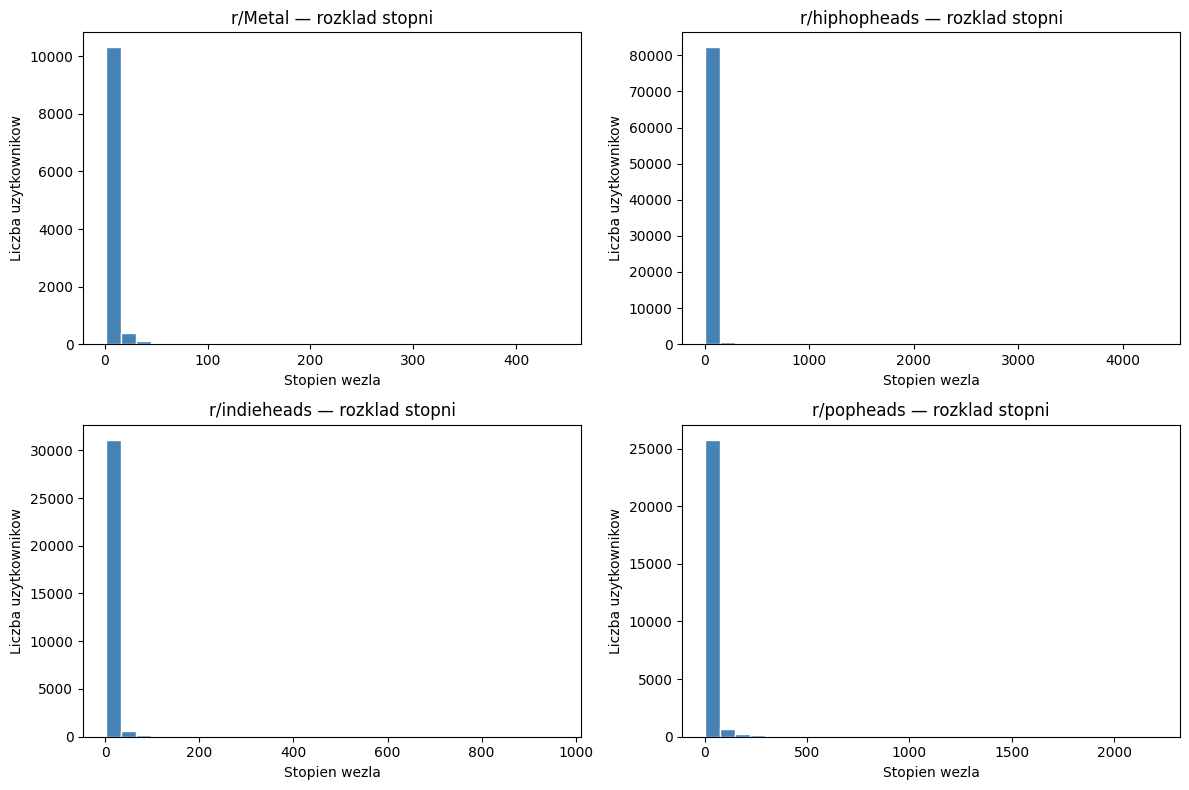

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    G_und = G.to_undirected()
    degrees = [d for _, d in G_und.degree()]
    
    axes[i].hist(degrees, bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(f"r/{sub} — rozklad stopni")
    axes[i].set_xlabel("Stopien wezla")
    axes[i].set_ylabel("Liczba uzytkownikow")

plt.tight_layout()
plt.savefig("../outputs/figures/degree_distribution.png", dpi=150)
plt.show()

## 3. Centralnosc

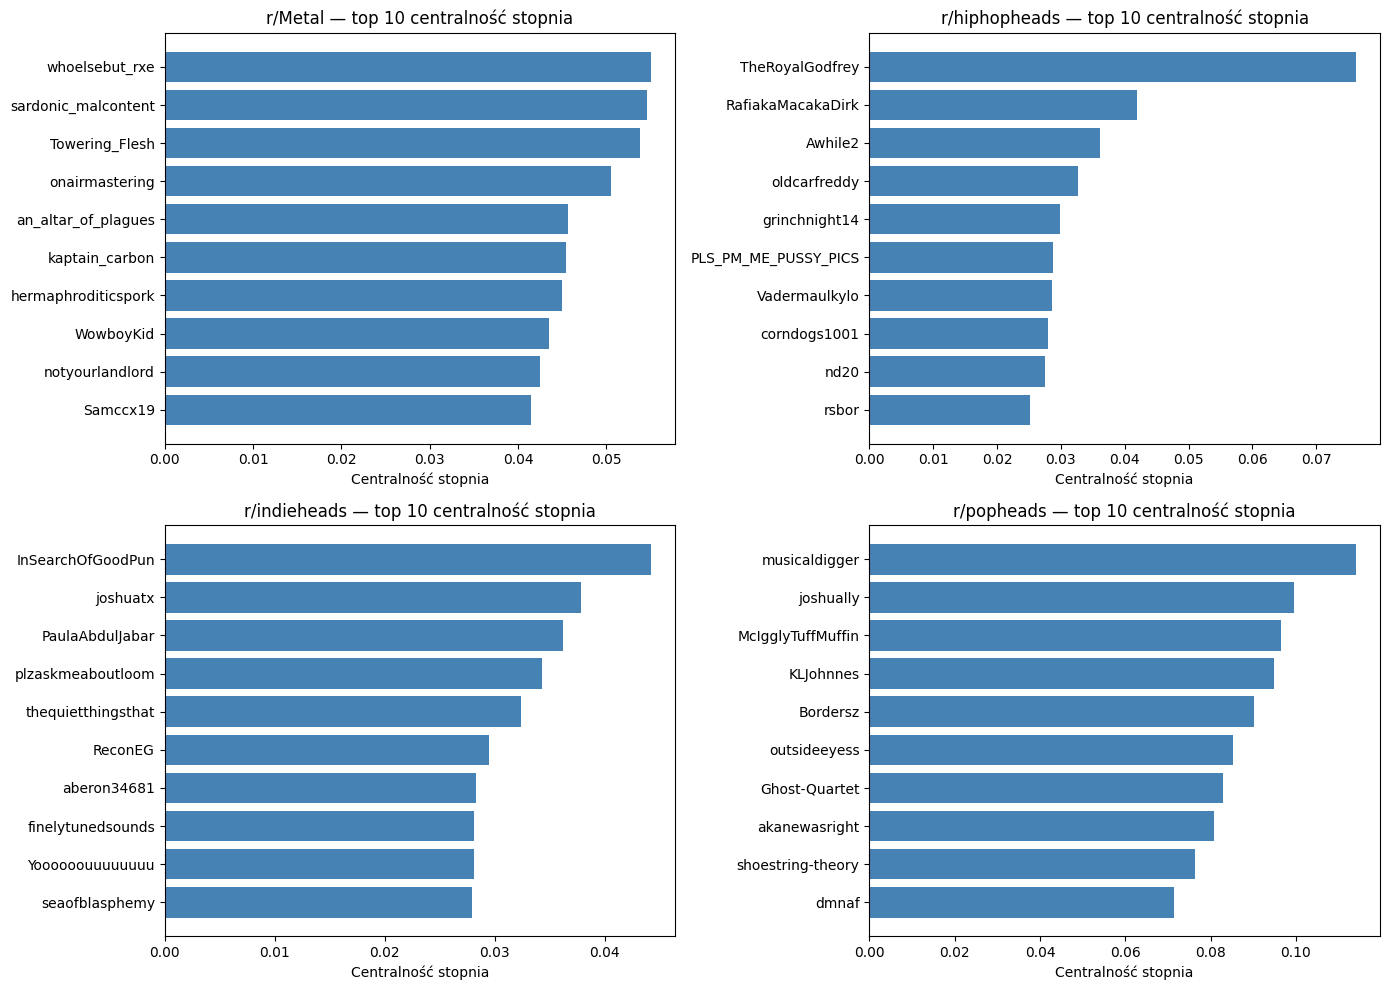

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    degree_cent = nx.degree_centrality(G)
    top = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    
    axes[i].barh(users, values, color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 centralność stopnia")
    axes[i].set_xlabel("Centralność stopnia")

plt.tight_layout()
plt.savefig("../outputs/figures/degree_centrality.png", dpi=150)
plt.show()

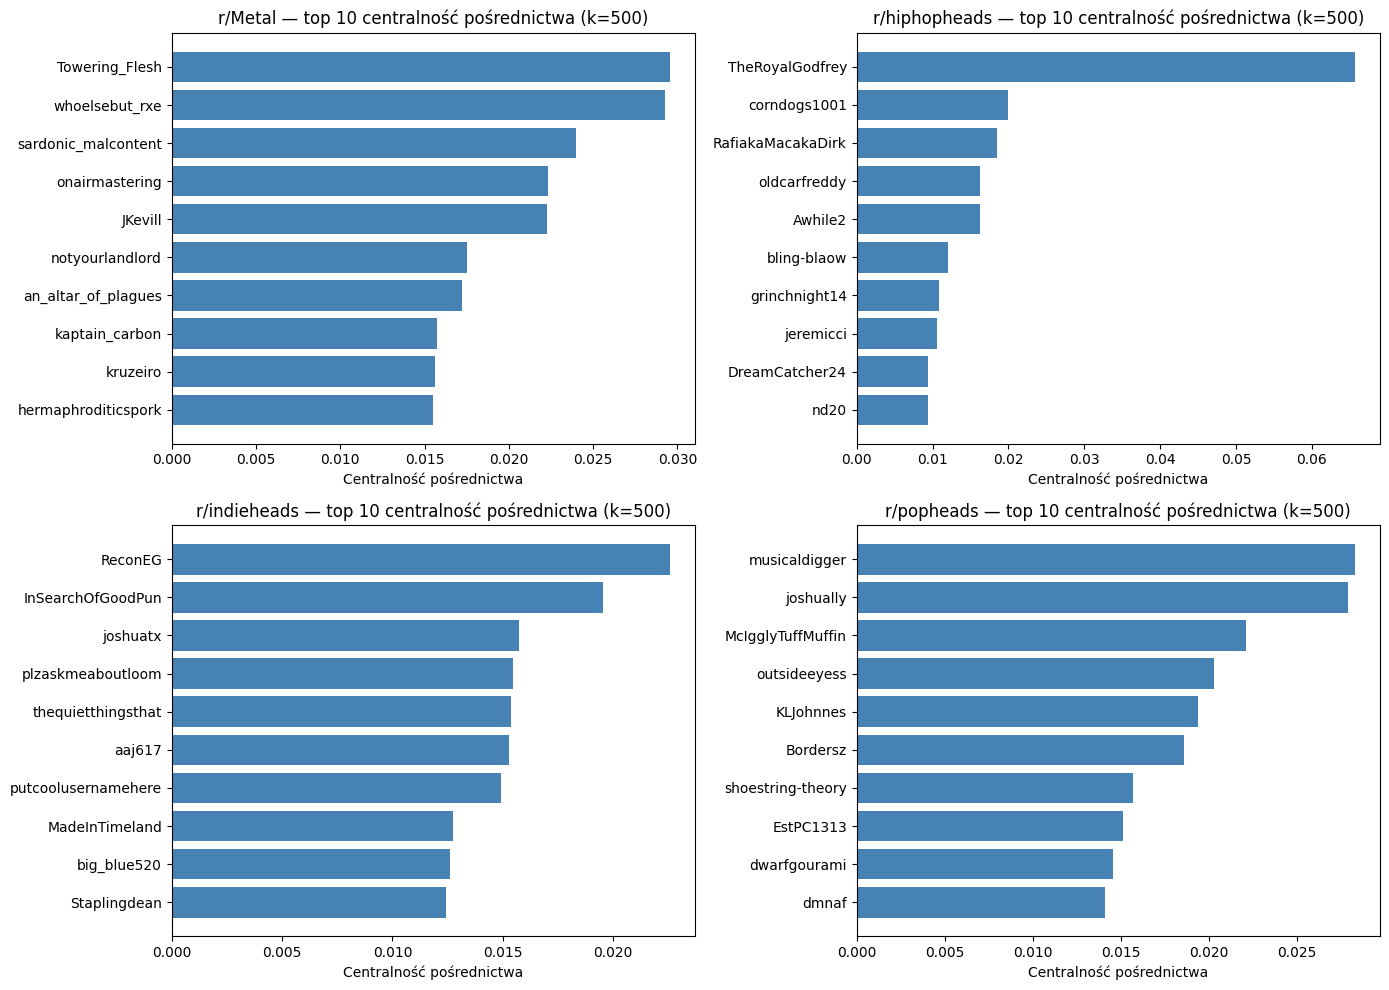

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    # k=500 oznacza przybliżone obliczenia na 500 losowych węzłach — znacznie szybciej
    between_cent = nx.betweenness_centrality(G, k=500)
    top = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    
    users  = [u for u, _ in top][::-1]
    values = [v for _, v in top][::-1]
    
    axes[i].barh(users, values, color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 centralność pośrednictwa (k=500)")
    axes[i].set_xlabel("Centralność pośrednictwa")

plt.tight_layout()
plt.savefig("../outputs/figures/betweenness_centrality.png", dpi=150)
plt.show()

## 4. Wykrywanie spolecznosci (Louvain)

In [10]:
community_stats = []

for sub, G in graphs.items():
    G_und = G.to_undirected()
    partition = community_louvain.best_partition(G_und)
    
    num_communities = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, G_und)
    sizes = Counter(partition.values())
    largest = max(sizes.values())
    
    community_stats.append({
        "subreddit":         sub,
        "communities":       num_communities,
        "modularity":        round(modularity, 3),
        "largest_community": largest,
    })
    
    nx.set_node_attributes(G, partition, "community")

community_df = pd.DataFrame(community_stats).set_index("subreddit")
community_df

,communities,modularity,largest_community
subreddit,,,
Metal,386,0.392,1885
hiphopheads,793,0.298,14632
indieheads,791,0.428,6448
popheads,315,0.197,5735


## 5. Wizualizacja sieci

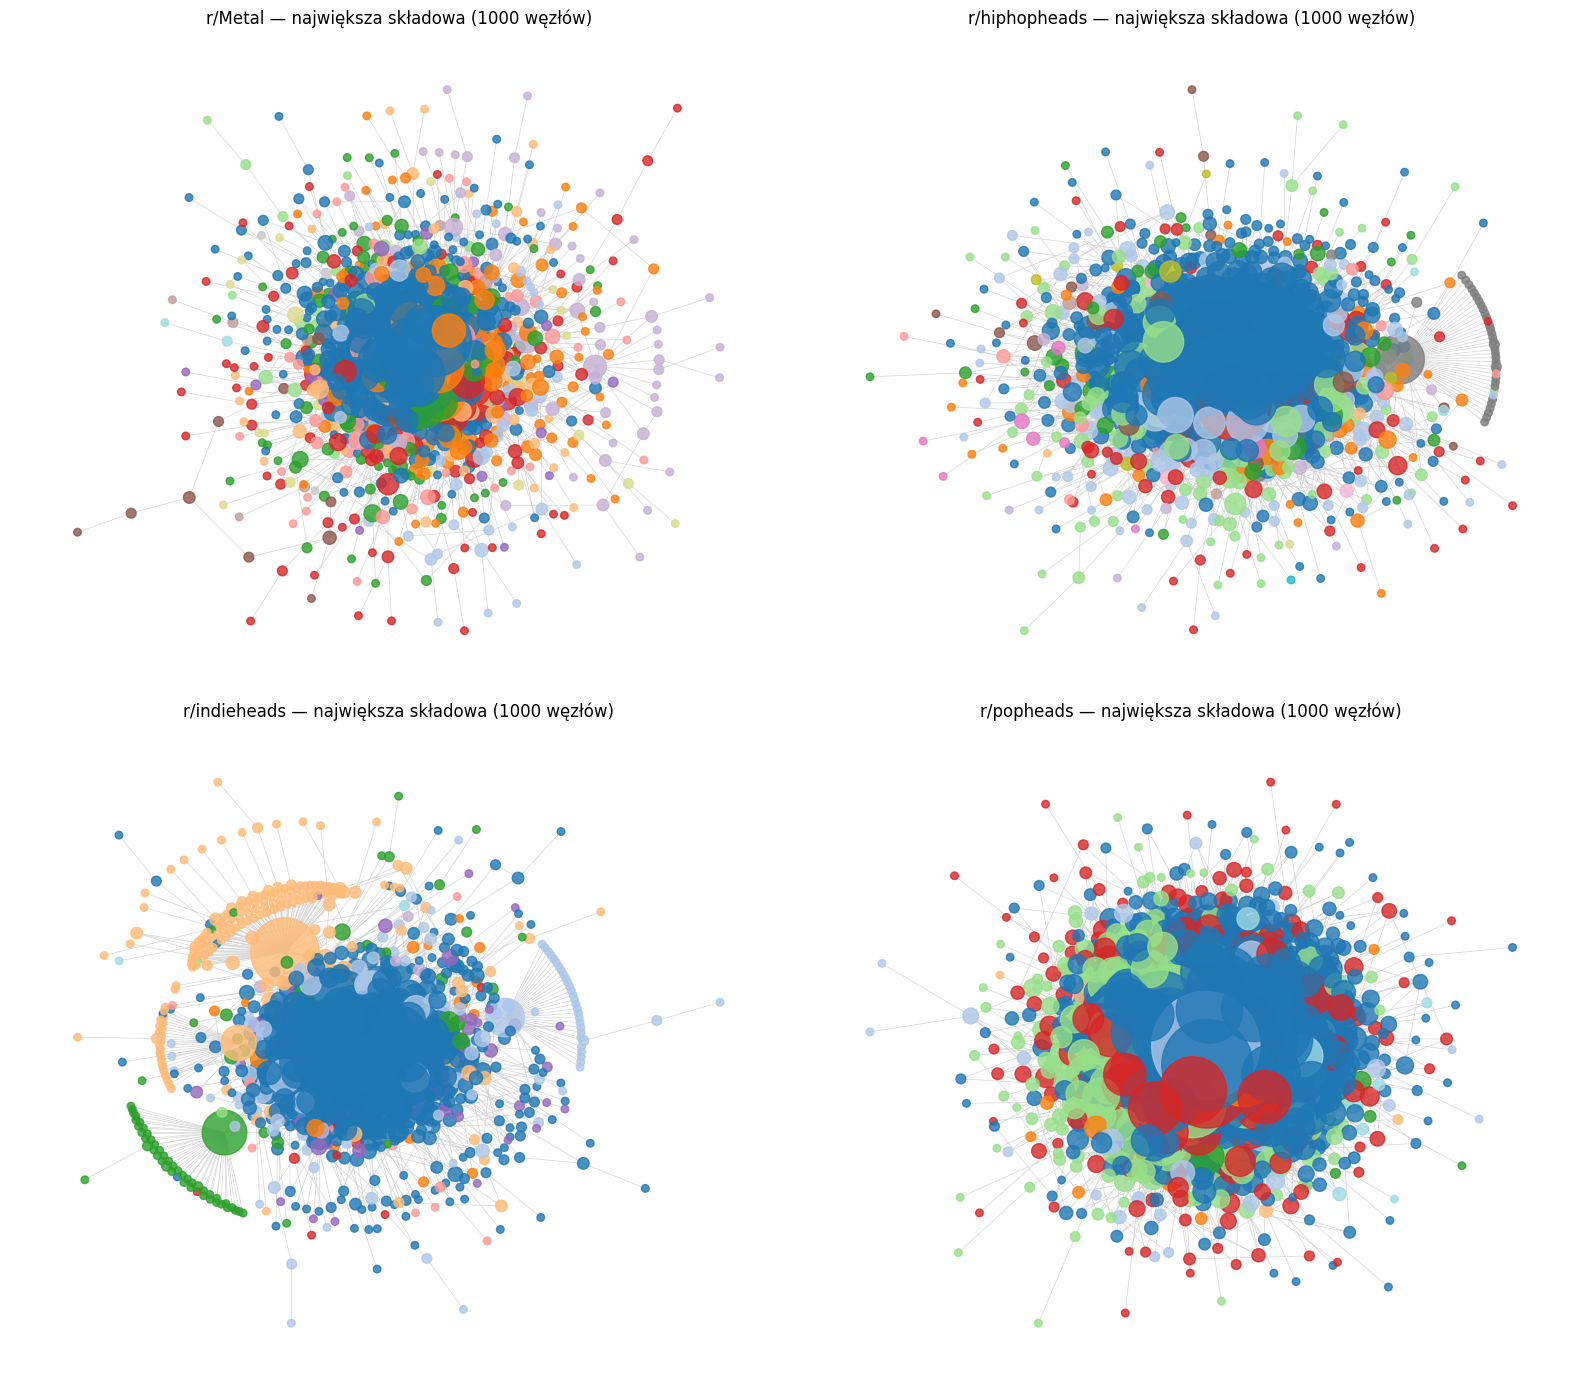

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (sub, G) in enumerate(graphs.items()):
    ax = axes[i]
    G_und = G.to_undirected()
    
    largest_cc = max(nx.connected_components(G_und), key=len)
    G_sub = G_und.subgraph(largest_cc)
    
    # jeśli sieć za duża, bierzemy tylko 1000 węzłów
    if len(G_sub) > 1000:
        nodes = list(G_sub.nodes())[:1000]
        G_sub = G_sub.subgraph(nodes)
    
    pos = nx.kamada_kawai_layout(G_sub)
    
    communities = nx.get_node_attributes(G, "community")
    node_colors = [communities.get(n, 0) for n in G_sub.nodes()]
    
    degrees = dict(G_sub.degree())
    node_sizes = [degrees[n] * 20 + 10 for n in G_sub.nodes()]
    
    nx.draw_networkx(
        G_sub,
        pos=pos,
        ax=ax,
        with_labels=False,
        node_color=node_colors,
        node_size=node_sizes,
        edge_color="#cccccc",
        width=0.5,
        cmap=plt.cm.tab20,
        alpha=0.8,
    )
    
    ax.set_title(f"r/{sub} — największa składowa ({len(G_sub)} węzłów)")
    ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/network_communities.png", dpi=150)
plt.show()

In [3]:
import plotly.graph_objects as go
from pathlib import Path

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

for sub, G in graphs.items():
    G_und = G.to_undirected()
    
    largest_cc = max(nx.connected_components(G_und), key=len)
    G_sub = G_und.subgraph(largest_cc)
    
    # bierzemy 10 najbardziej połączonych węzłów zamiast losowych
    if len(G_sub) > 10:
        top_nodes = sorted(G_sub.degree(), key=lambda x: x[1], reverse=True)[:10]
        top_nodes = [n for n, _ in top_nodes]
        G_sub = G_sub.subgraph(top_nodes)
    
    pos = nx.spring_layout(G_sub, dim=3, seed=42, k=1.5)
    
    communities = nx.get_node_attributes(G, "community")
    degrees = dict(G_sub.degree())
    
    # krawędzie
    edge_x, edge_y, edge_z = [], [], []
    for u, v in G_sub.edges():
        x0, y0, z0 = pos[u]
        x1, y1, z1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]
    
    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode="lines",
        line=dict(color="#aaaaaa", width=1),
        hoverinfo="none"
    )
    
    # węzły
    node_x = [pos[n][0] for n in G_sub.nodes()]
    node_y = [pos[n][1] for n in G_sub.nodes()]
    node_z = [pos[n][2] for n in G_sub.nodes()]
    node_colors = [communities.get(n, 0) for n in G_sub.nodes()]
    node_sizes = [degrees[n] * 2 + 5 for n in G_sub.nodes()]
    
    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode="markers+text",
        marker=dict(
            size=node_sizes,
            color=node_colors,
            colorscale="Viridis",
            opacity=0.9,
        ),
        text=list(G_sub.nodes()),
        textposition="top center",
        textfont=dict(size=8),
        hoverinfo="text"
    )
    
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=f"r/{sub} — top 10 użytkowników (sieć 3D)",
            showlegend=False,
            scene=dict(
                xaxis=dict(showticklabels=False, title=""),
                yaxis=dict(showticklabels=False, title=""),
                zaxis=dict(showticklabels=False, title=""),
                bgcolor="white",
            ),
            paper_bgcolor="white",
        )
    )
    
    out_path = f"../outputs/figures/network_3d_{sub}.html"
    fig.write_html(out_path)
    print(f"Zapisano → {out_path}")

NameError: name 'graphs' is not defined

## Wnioski

- ...
- ...
- ...